# Preprocessing & EDA
## Healthcare Sector Focus

**Goal**: Analyse the UK ICO data security incident trends with a focus on the healthcare sector to prepare for building ML models and a dashboard.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes

# Constants 
COLOUR_PALETTE = ["#f47d9b", "#7be289", "#f3dc4a", "#8097e8","#e8a16e", "#d585ed", "#60e1e1"]

In [3]:
# load the dataset
df_ico_original = pd.read_csv("data/data-security-incidents-trends-q1-2019-to-q4-2025.csv", delimiter = ",")

# initial look at data
df_ico_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206140 entries, 0 to 206139
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   BI Reference                206140 non-null  object
 1   Year                        206140 non-null  int64 
 2   Quarter                     206140 non-null  object
 3   Data Subject Type           206140 non-null  object
 4   Data Type                   206140 non-null  object
 5   Decision Taken              206140 non-null  object
 6   Incident Category           206140 non-null  object
 7   Incident Type               206140 non-null  object
 8   No. Data Subjects Affected  206140 non-null  object
 9   Sector                      206140 non-null  object
 10  Time Taken to Report        206140 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.3+ MB


In [4]:
# Function to plot vertical bar chart with counts and percentages
def plot_vertical_bar_chart(series, title, xlabel=None, ylabel="Count", sort_by='value', figsize=(10, 6), annotate='both', total=None, rotation=45, color=COLOUR_PALETTE, step=500):
    # Sort the series
    if sort_by == 'value':
        series = series.sort_values(ascending=False)
    elif sort_by == 'index':
        series = series.sort_index()
    # else: leave as it is

    # Calculate percentages
    categories = series.index.astype(str)
    counts = series.values
    denom = total if total is not None else counts.sum()
    percents = (counts / denom) * 100 if denom else counts * 0

    # Create the bar chart
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(categories, counts, color=color[:len(categories)], edgecolor='white')

    # Formatting the bar chart
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel if xlabel is not None else (series.index.name or ""))
    ax.set_ylabel(ylabel)
    ax.set_yticks(np.arange(0, counts.max() * 1.2, step))
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=rotation, ha='right' if rotation else 'center')
    ax.grid(True, axis='y', linestyle='-', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Headroom for the labels
    if counts.max() > 0:
        ax.set_ylim(0, counts.max() * 1.15)

    # Annotate
    if annotate:
        for bar, cnt, pct in zip(bars, counts, percents):
            if annotate == 'count':
                label = f"{cnt:,}"
            elif annotate == 'percent':
                label = f"{pct:.1f}%"
            else:
                label = f"{cnt:,}\n({pct:.1f}%)"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                label,
                ha='center',
                va='bottom',
                fontsize=9,
            )

    # Show the plot
    plt.tight_layout()
    plt.show()

    # Return summary df
    summary = pd.DataFrame({'count': counts, 'percent': percents.round(1)}, index=categories)
    return summary

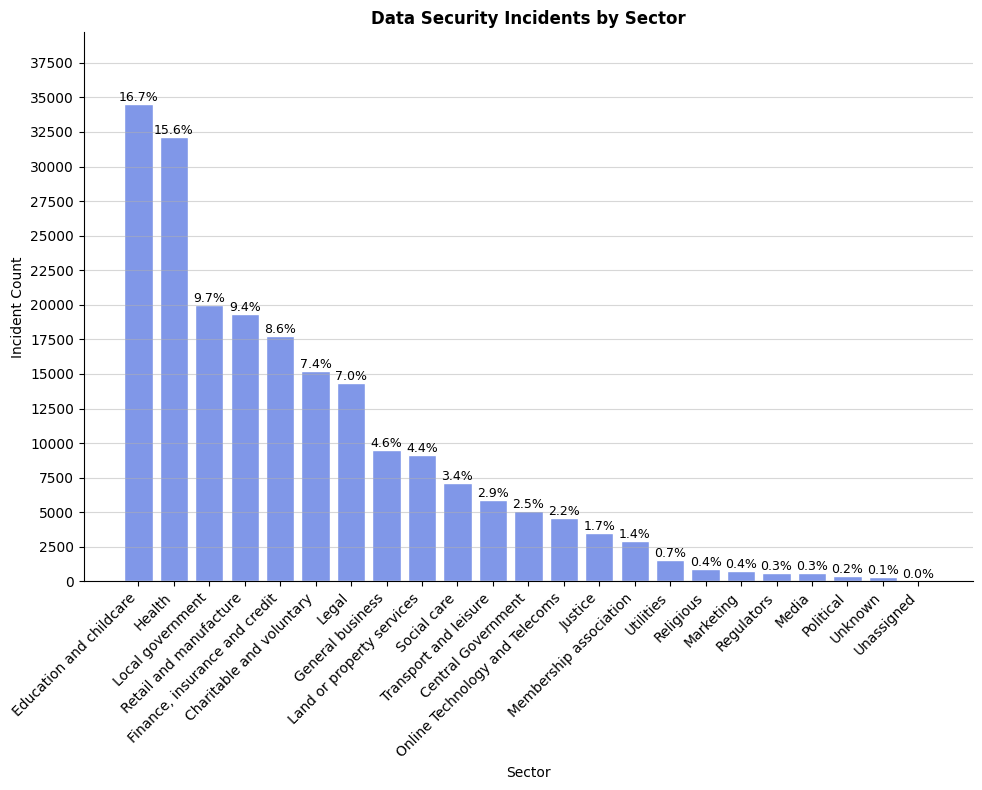


Total sectors: 23
                                count  percent
Sector                                        
Education and childcare         34525     16.7
Health                          32127     15.6
Local government                19991      9.7
Retail and manufacture          19308      9.4
Finance, insurance and credit   17744      8.6
Charitable and voluntary        15229      7.4
Legal                           14329      7.0
General business                 9520      4.6
Land or property services        9148      4.4
Social care                      7103      3.4
Transport and leisure            5908      2.9
Central Government               5054      2.5
Online Technology and Telecoms   4614      2.2
Justice                          3503      1.7
Membership association           2937      1.4
Utilities                        1536      0.7
Religious                         894      0.4
Marketing                         769      0.4
Regulators                        619    

In [5]:
# Plot the sector distribution
sector_counts = df_ico_original['Sector'].value_counts()
sector_summary = plot_vertical_bar_chart(
    sector_counts,
    title="Data Security Incidents by Sector",
    xlabel="Sector",
    ylabel="Incident Count",
    sort_by='none',
    figsize=(10, 8),
    annotate='percent', 
    color="#8097e8",
    step=2500
)

print(f"\nTotal sectors: {df_ico_original['Sector'].nunique()}")
print(sector_summary)

In [6]:
# filtering the database to focus of the health sector
df_health_original = df_ico_original[df_ico_original["Sector"] == "Health"].copy(deep=True)

# drop the sector column as it's redundant now
df_health_original = df_health_original.drop(columns=["Sector"])

# standardising the column names
df_health_original.columns = df_health_original.columns.str.strip().str.lower().str.replace(" ", "_").str.replace(".", "")

# look at new healthcare sector focused df
df_health_original.info()
#df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 32127 entries, 12 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   bi_reference               32127 non-null  object
 1   year                       32127 non-null  int64 
 2   quarter                    32127 non-null  object
 3   data_subject_type          32127 non-null  object
 4   data_type                  32127 non-null  object
 5   decision_taken             32127 non-null  object
 6   incident_category          32127 non-null  object
 7   incident_type              32127 non-null  object
 8   no_data_subjects_affected  32127 non-null  object
 9   time_taken_to_report       32127 non-null  object
dtypes: int64(1), object(9)
memory usage: 2.7+ MB


In [7]:
# filtering timeframe to Q2 2021 to Q2 2025

# Get quarters as int for filtering
df_health_original["quarter_num"] = df_health_original["quarter"].str.extract(r"(\d)").astype(int) # temp, helper column 

df_health_original = df_health_original[
    ((df_health_original["year"] > 2021) | ((df_health_original["year"] == 2021) & (df_health_original["quarter_num"] >= 2))) &
    ((df_health_original["year"] < 2025) | ((df_health_original["year"] == 2025) & (df_health_original["quarter_num"] <= 4)))
]

df_health_original = df_health_original.drop(columns="quarter_num") # drop 

# Test to see full timeframe
print(df_health_original[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]).to_string(index=False))

# New CSV of all processed data
#df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

 year quarter
 2021   Qtr 2
 2021   Qtr 3
 2021   Qtr 4
 2022   Qtr 1
 2022   Qtr 2
 2022   Qtr 3
 2022   Qtr 4
 2023   Qtr 1
 2023   Qtr 2
 2023   Qtr 3
 2023   Qtr 4
 2024   Qtr 1
 2024   Qtr 2
 2024   Qtr 3
 2024   Qtr 4
 2025   Qtr 1
 2025   Qtr 2
 2025   Qtr 3
 2025   Qtr 4


In [8]:
# change data type of features into categorical instead of object/ int as characteristics are fixed
categorical_cols = [
    "bi_reference",
    "year",
    "quarter",
    "data_subject_type",
    "data_type",
    "decision_taken",
    "incident_category",
    "incident_type",
    "no_data_subjects_affected",
    "time_taken_to_report"
]


for col in categorical_cols:
    df_health_original[col] = df_health_original[col].astype("category")

# verify new data types
df_health_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22879 entries, 65264 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               22879 non-null  category
 1   year                       22879 non-null  category
 2   quarter                    22879 non-null  category
 3   data_subject_type          22879 non-null  category
 4   data_type                  22879 non-null  category
 5   decision_taken             22879 non-null  category
 6   incident_category          22879 non-null  category
 7   incident_type              22879 non-null  category
 8   no_data_subjects_affected  22879 non-null  category
 9   time_taken_to_report       22879 non-null  category
dtypes: category(10)
memory usage: 764.5 KB


In [9]:
# Order the data subjects affected category
df_health_original["no_data_subjects_affected"] = pd.Categorical(
    df_health_original["no_data_subjects_affected"],
    categories=[
        "1 to 9",
        "10 to 99",
        "100 to 1k",
        "1k to 10k",
        "10k to 100k",
        "100k and above",
        "Unknown"
    ],
    ordered=True
)

# verify ordering
df_health_original["no_data_subjects_affected"].cat.categories

Index(['1 to 9', '10 to 99', '100 to 1k', '1k to 10k', '10k to 100k',
       '100k and above', 'Unknown'],
      dtype='object')

In [10]:
# Finding the unique vs total BI references 
total_rows = len(df_health_original)
unique_bi_refs = df_health_original['bi_reference'].nunique()
duplicate_ratio = (total_rows - unique_bi_refs) / total_rows * 100

print(f"\nTotal rows in the dataset: {total_rows:,}")
print(f"Unique BI References: {unique_bi_refs:,}")
print(f"Rows representing duplicate characteristics: {total_rows - unique_bi_refs:,}")
print(f"Duplication rate: {duplicate_ratio:.2f}%")


Total rows in the dataset: 22,879
Unique BI References: 10,098
Rows representing duplicate characteristics: 12,781
Duplication rate: 55.86%


In [11]:
# Function to plot pie chart with counts and percentages
def plot_pie_with_counts(series, title, total, colors=COLOUR_PALETTE):
    counts = series.values
    categories = series.index
    percents = (counts / total) * 100

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(title, fontsize=12, fontweight='bold')

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=[str(cat) for cat in categories],
        autopct='%1.1f%%',
        labeldistance=1.1, 
        colors=colors[:len(categories)],
        startangle=90,
        textprops={'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    )

    ax.axis('equal')
    plt.tight_layout()
    plt.show()
    
    # Return summary df
    summary = pd.DataFrame({'count': counts, 'percent': percents.round(1)}, index=categories)
    return summary

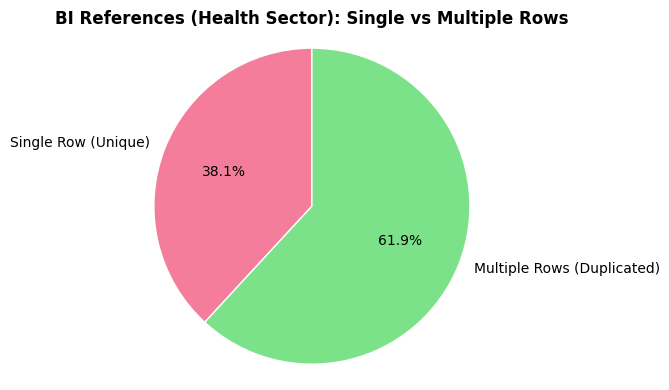

                            count  percent
Single Row (Unique)          3851     38.1
Multiple Rows (Duplicated)   6247     61.9


In [12]:
# Plot the breakdown of unique vs duplicate BI references
bi_ref_counts = df_health_original['bi_reference'].value_counts()
bi_ref_series = pd.Series({
    'Single Row (Unique)': (bi_ref_counts == 1).sum(),
    'Multiple Rows (Duplicated)': (bi_ref_counts > 1).sum(),
})

bi_ref_summary = plot_pie_with_counts(
    bi_ref_series,
    title='BI References (Health Sector): Single vs Multiple Rows',
    total=bi_ref_series.sum(),
)
print(bi_ref_summary)

In [13]:
# analyse which columns typically vary across duplicates
duplicated_bi_refs = df_health_original[df_health_original['bi_reference'].duplicated(keep=False)]
total_groups = duplicated_bi_refs['bi_reference'].nunique()

# nunique per group per column
varying_columns = duplicated_bi_refs.groupby("bi_reference", observed=False).nunique()

# a column varies in a group if nunique > 1
varying_counts = (varying_columns > 1).sum()

varying_counts = (varying_counts
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

varying_counts["percentage"] = (varying_counts["count"] / total_groups * 100)

print(f"Columns that vary across duplicate rows:\n {varying_counts}")

# summarise how many characteristics each breach has
print("\nBreach characteristics per incident:")
df_health_original.groupby("bi_reference", observed=False).size().describe()

Columns that vary across duplicate rows:
                            count  percentage
data_type                   5675   90.843605
data_subject_type           1689   27.036978
year                           0    0.000000
quarter                        0    0.000000
decision_taken                 0    0.000000
incident_category              0    0.000000
incident_type                  0    0.000000
no_data_subjects_affected      0    0.000000
time_taken_to_report           0    0.000000

Breach characteristics per incident:


count    10098.000000
mean         2.265696
std          2.808294
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         66.000000
dtype: float64

In [32]:
# Create a new df that only contains unique BI references (deduplicated)
df_health_unique = df_health_original.drop_duplicates(subset=["bi_reference"], keep="first").reset_index(drop=True)
print("Unique Rows in Health Sector df:",unique_bi_refs)

Unique Rows in Health Sector df: 10098


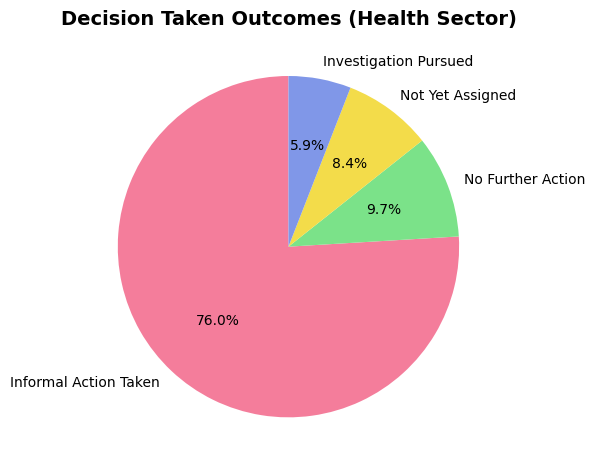

Decision taken counts:
Informal Action Taken:	7,670 
No Further Action:	982 
Investigation Pursued:	598 
Not Yet Assigned:	848


In [33]:
# decision taken outcomes
decision_counts = df_health_unique['decision_taken'].value_counts()
decision_percents = (decision_counts / len(df_health_original)) * 100

# pie chart
plt.title("Decision Taken Outcomes (Health Sector)", fontsize=14, fontweight='bold')
plt.pie(decision_counts.values,
        labels=decision_counts.index,
        autopct='%1.1f%%',
        colors=COLOUR_PALETTE[:len(decision_counts)],
        startangle=90,
        textprops={'fontsize': 10})

plt.tight_layout()
plt.show()

print(f"Decision taken counts:\nInformal Action Taken:\t{decision_counts['Informal Action Taken']:,} \nNo Further Action:\t{decision_counts['No Further Action']:,} \nInvestigation Pursued:\t{decision_counts['Investigation Pursued']:,} \nNot Yet Assigned:\t{decision_counts['Not Yet Assigned']:,}")


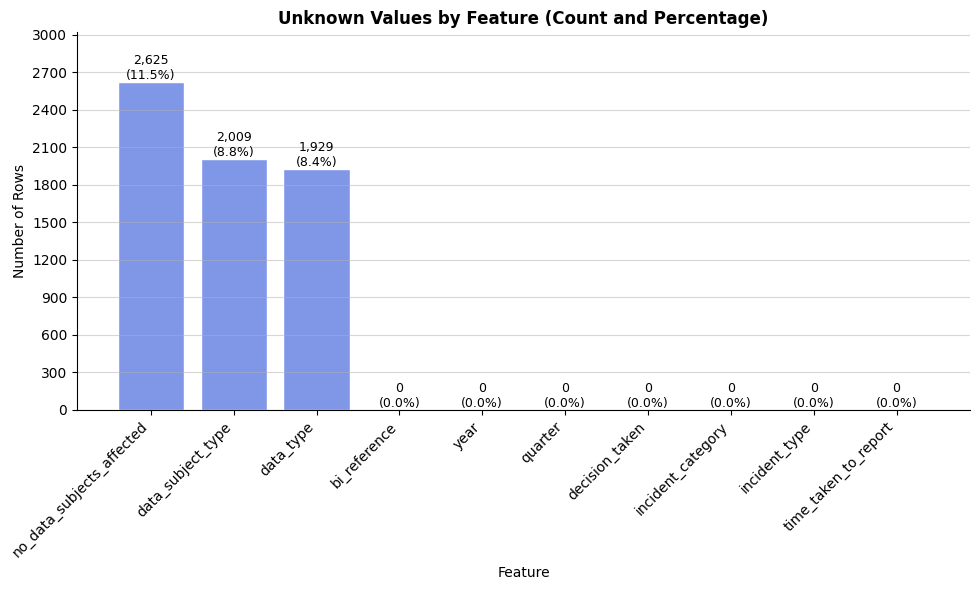

                           count  percent
no_data_subjects_affected   2625     11.5
data_subject_type           2009      8.8
data_type                   1929      8.4
bi_reference                   0      0.0
year                           0      0.0
quarter                        0      0.0
decision_taken                 0      0.0
incident_category              0      0.0
incident_type                  0      0.0
time_taken_to_report           0      0.0


In [14]:
unknown_counts = (
    df_health_original[categorical_cols]
    .isin(["Unknown"]).sum()
    .sort_values(ascending=False)
)

summary = plot_vertical_bar_chart(
    unknown_counts,
    title="Unknown Values by Feature (Count and Percentage)",
    xlabel="Feature",
    ylabel="Number of Rows",
    sort_by='none',
    total=len(df_health_original),
    annotate='both',
    color="#8097e8",
    step=300
)
print(summary)

In [16]:
# aggregate total rows per year-quarter (duplicated BI references)
total_incidents = (
    df_health_original
    .groupby(["year", "quarter"], observed=True) 
    .size()
    .reset_index(name="total_incidents")
)

# aggregate unique incidents per year-quarter (non-duplicated BI references)
unique_incidents = (
    df_health_unique
    .groupby(["year", "quarter"], observed=True)  
    .size()
    .reset_index(name="unique_incidents")
)

quarters = {"Qtr 1": 1, "Qtr 2": 2, "Qtr 3": 3, "Qtr 4": 4}

# merge the two summaries
incidents_over_time = total_incidents.merge(unique_incidents, on=["year", "quarter"])

# make the chronological order
incidents_over_time["quarter_num"] = incidents_over_time["quarter"].astype(str).map(quarters)

# convert year to int for sorting
incidents_over_time["year_num"] = incidents_over_time["year"].astype(str).astype(int)
incidents_over_time = incidents_over_time.sort_values(by=["year_num", "quarter_num"]).reset_index(drop=True)

# x-axis label
incidents_over_time["period"] = (incidents_over_time["year"].astype(str) + " " + incidents_over_time["quarter"].astype(str))

# copy for display purposes
display_df = incidents_over_time[["year", "quarter", "total_incidents", "unique_incidents"]].copy()
# calculate the difference (duplicate count) & percentage of duplicates
display_df["duplicates"] = display_df["total_incidents"] - display_df["unique_incidents"]
# display columns
display_df.columns = ["Year", "Quarter", "Total Rows", "Unique Incidents", "Duplicates"]

# tabular form
print("Healthcare data security incidents over time:")
print(display_df.to_string(index=False))

# summary statistics
print(f"\nOverall Summary:")
print(f"\tTotal rows across all periods: {display_df['Total Rows'].sum():,}")
print(f"\tTotal unique incidents: {display_df['Unique Incidents'].sum():,}")
print(f"\tTotal duplicate incidents: {display_df['Duplicates'].sum():,}")

# mean and standard deviations of unique incidents over time 
print(f"\tMean incidents per quarter: {display_df['Unique Incidents'].mean():.1f}")
print(f"\tStandard deviation of incidents: {display_df['Unique Incidents'].std():.1f}")
print(f"\tMaximum incidents in a quarter: {display_df['Unique Incidents'].max():,}")
print(f"\tMinimum incidents in a quarter: {display_df['Unique Incidents'].min():,}")

Healthcare data security incidents over time:
Year Quarter  Total Rows  Unique Incidents  Duplicates
2021   Qtr 2        1286               603         683
2021   Qtr 3         915               432         483
2021   Qtr 4         991               461         530
2022   Qtr 1         913               421         492
2022   Qtr 2         937               431         506
2022   Qtr 3        1548               481        1067
2022   Qtr 4         938               440         498
2023   Qtr 1        1077               454         623
2023   Qtr 2        1019               458         561
2023   Qtr 3        1038               501         537
2023   Qtr 4        1191               503         688
2024   Qtr 1        1245               572         673
2024   Qtr 2        1497               616         881
2024   Qtr 3        1620               677         943
2024   Qtr 4        1154               577         577
2025   Qtr 1        1231               582         649
2025   Qtr 2       

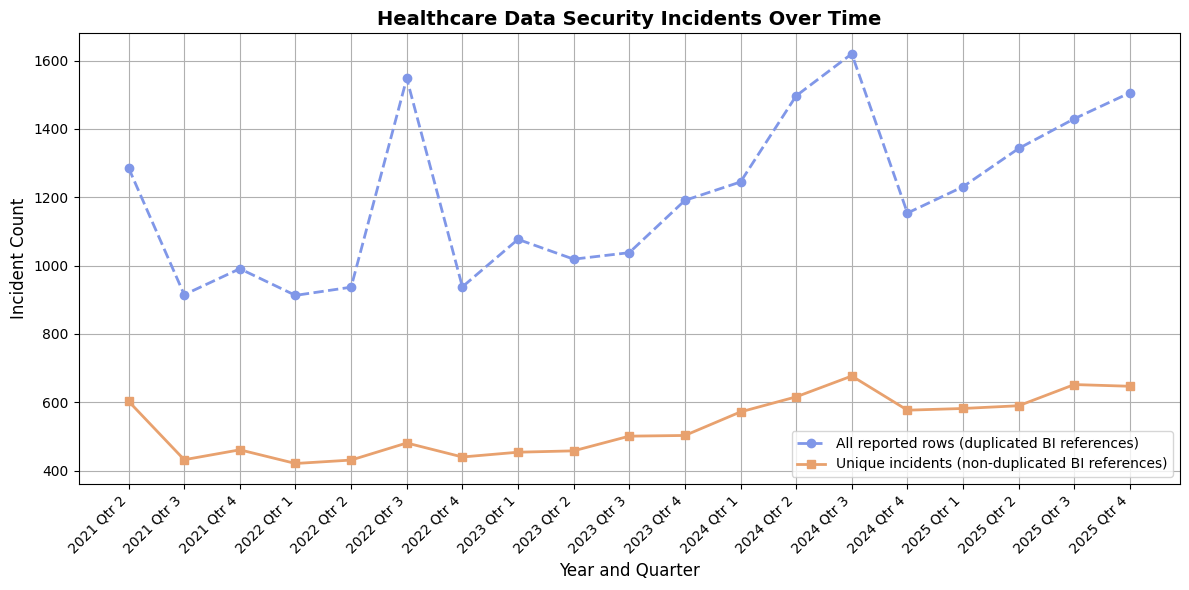

In [17]:
# graph visualisation of incidents 
plt.figure(figsize=(12, 6))

plt.plot(
    incidents_over_time.index,
    incidents_over_time["total_incidents"],
    marker='o',
    label="All reported rows (duplicated BI references)",
    linestyle="--",
    linewidth=2,
    markersize=6,
    color="#8097e8"
)

plt.plot(
    incidents_over_time.index,
    incidents_over_time["unique_incidents"],
    marker='s',
    label="Unique incidents (non-duplicated BI references)",
    linewidth=2,
    markersize=6,
    color="#e8a16e"
)

plt.xticks(
    ticks=incidents_over_time.index,
    labels=incidents_over_time["period"],
    rotation=45, ha='right'
)

plt.title("Healthcare Data Security Incidents Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year and Quarter", fontsize=12)
plt.ylabel("Incident Count", fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle='-')
plt.tight_layout()
plt.show()

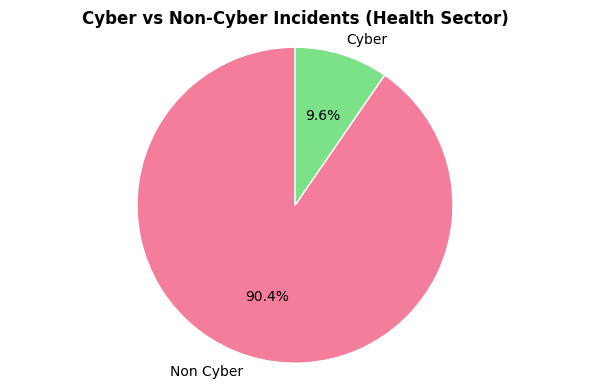

                   count  percent
incident_category                
Non Cyber           9129     39.9
Cyber                969      4.2


In [18]:
# Cyber vs Non-Cyber Incidents pie chart 
incident_category_counts = df_health_unique['incident_category'].value_counts()
incident_category_percents = (incident_category_counts / len(df_health_original)) * 100

summary = plot_pie_with_counts(
    incident_category_counts,
    title="Cyber vs Non-Cyber Incidents (Health Sector)",
    total=len(df_health_original),
    colors=COLOUR_PALETTE[:2]
)
print(summary)

In [20]:
# Function for plotting a crosstab bar chart
def plot_horizontal_stacked_crosstab(
    row_series,
    col_series,
    title,
    row_label=None,
    col_label=None,
    colormap='plasma',
    figsize=(16, 8),
    sort_by_size=True,
    show_table=True
):
    row_label = row_label or row_series.name or "Row"
    col_label = col_label or col_series.name or "Column"

    counts = pd.crosstab(row_series, col_series)
    proportions = pd.crosstab(row_series, col_series, normalize='index')

    if sort_by_size:
        order = counts.sum(axis=1).sort_values(ascending=True).index
        counts = counts.loc[order]
        proportions = proportions.loc[order]

    ax = proportions.plot(
        kind='barh',
        stacked=True,
        figsize=figsize,
        colormap=colormap,
        edgecolor='white',
        linewidth=0.5,
    )

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Proportion of {col_label}', fontsize=14)
    ax.set_ylabel(row_label, fontsize=14)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
    ax.legend(title=col_label, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='x', linestyle='-', alpha=0.5)

    plt.tight_layout()
    plt.show()

    if show_table:
        return proportions.round(3), counts
    return None

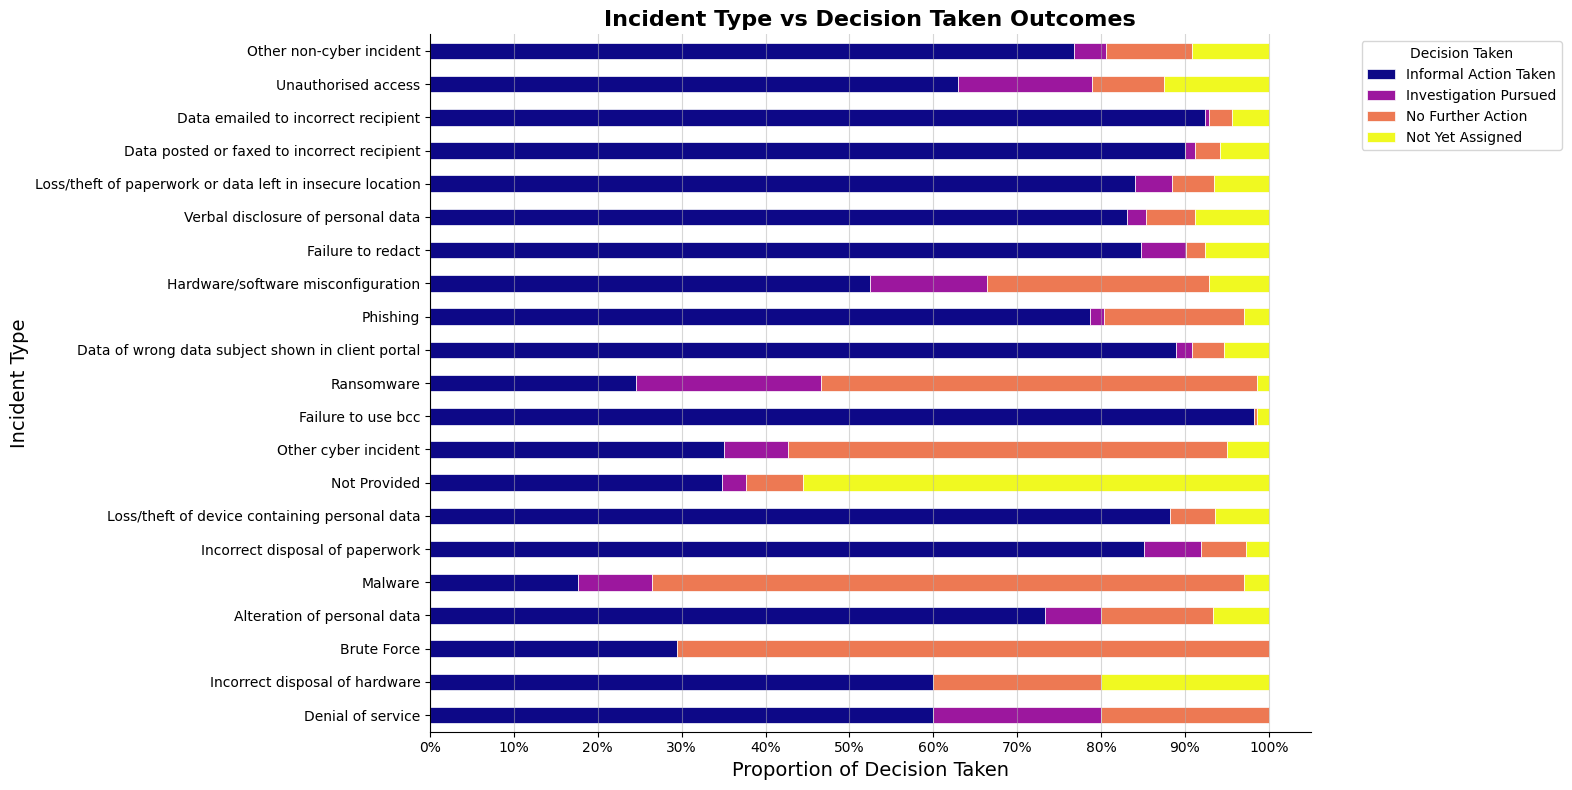

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
incident_type,,,,
Denial of service,0.600,0.200,0.200,0.000
Incorrect disposal of hardware,0.600,0.000,0.200,0.200
Brute Force,0.294,0.000,0.706,0.000
Alteration of personal data,0.733,0.067,0.133,0.067
Malware,0.176,0.088,0.706,0.029
Incorrect disposal of paperwork,0.851,0.068,0.054,0.027
Loss/theft of device containing personal data,0.882,0.000,0.055,0.064
Not Provided,0.349,0.028,0.069,0.555
Other cyber incident,0.350,0.077,0.523,0.050


In [21]:
# Incident type vs decision taken
props, counts = plot_horizontal_stacked_crosstab(
    df_health_unique['incident_type'],
    df_health_unique['decision_taken'],
    title='Incident Type vs Decision Taken Outcomes',
    row_label='Incident Type',
    col_label='Decision Taken',
)
display(props)

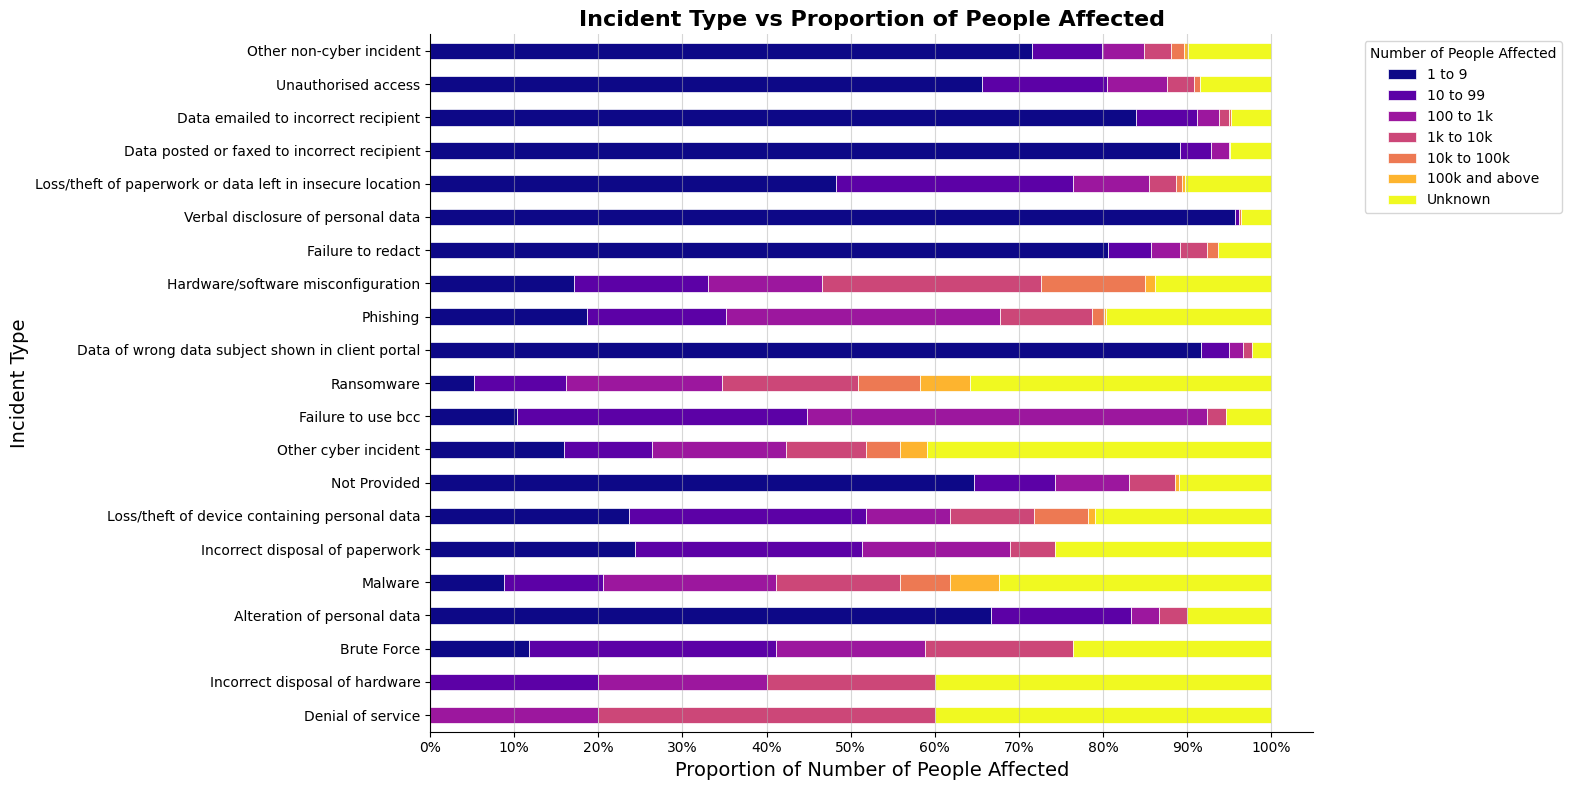

no_data_subjects_affected,1 to 9,10 to 99,100 to 1k,1k to 10k,10k to 100k,100k and above,Unknown
incident_type,,,,,,,
Denial of service,0.000,0.000,0.200,0.400,0.000,0.000,0.400
Incorrect disposal of hardware,0.000,0.200,0.200,0.200,0.000,0.000,0.400
Brute Force,0.118,0.294,0.176,0.176,0.000,0.000,0.235
Alteration of personal data,0.667,0.167,0.033,0.033,0.000,0.000,0.100
Malware,0.088,0.118,0.206,0.147,0.059,0.059,0.324
Incorrect disposal of paperwork,0.243,0.270,0.176,0.054,0.000,0.000,0.257
Loss/theft of device containing personal data,0.236,0.282,0.100,0.100,0.064,0.009,0.209
Not Provided,0.647,0.096,0.087,0.055,0.000,0.005,0.110
Other cyber incident,0.159,0.105,0.159,0.095,0.041,0.032,0.409


In [22]:
# Incident type vs number of people affected
props, counts = plot_horizontal_stacked_crosstab(
    df_health_unique['incident_type'],
    df_health_unique['no_data_subjects_affected'],
    title='Incident Type vs Proportion of People Affected',
    row_label='Incident Type',
    col_label='Number of People Affected',
)
display(props)

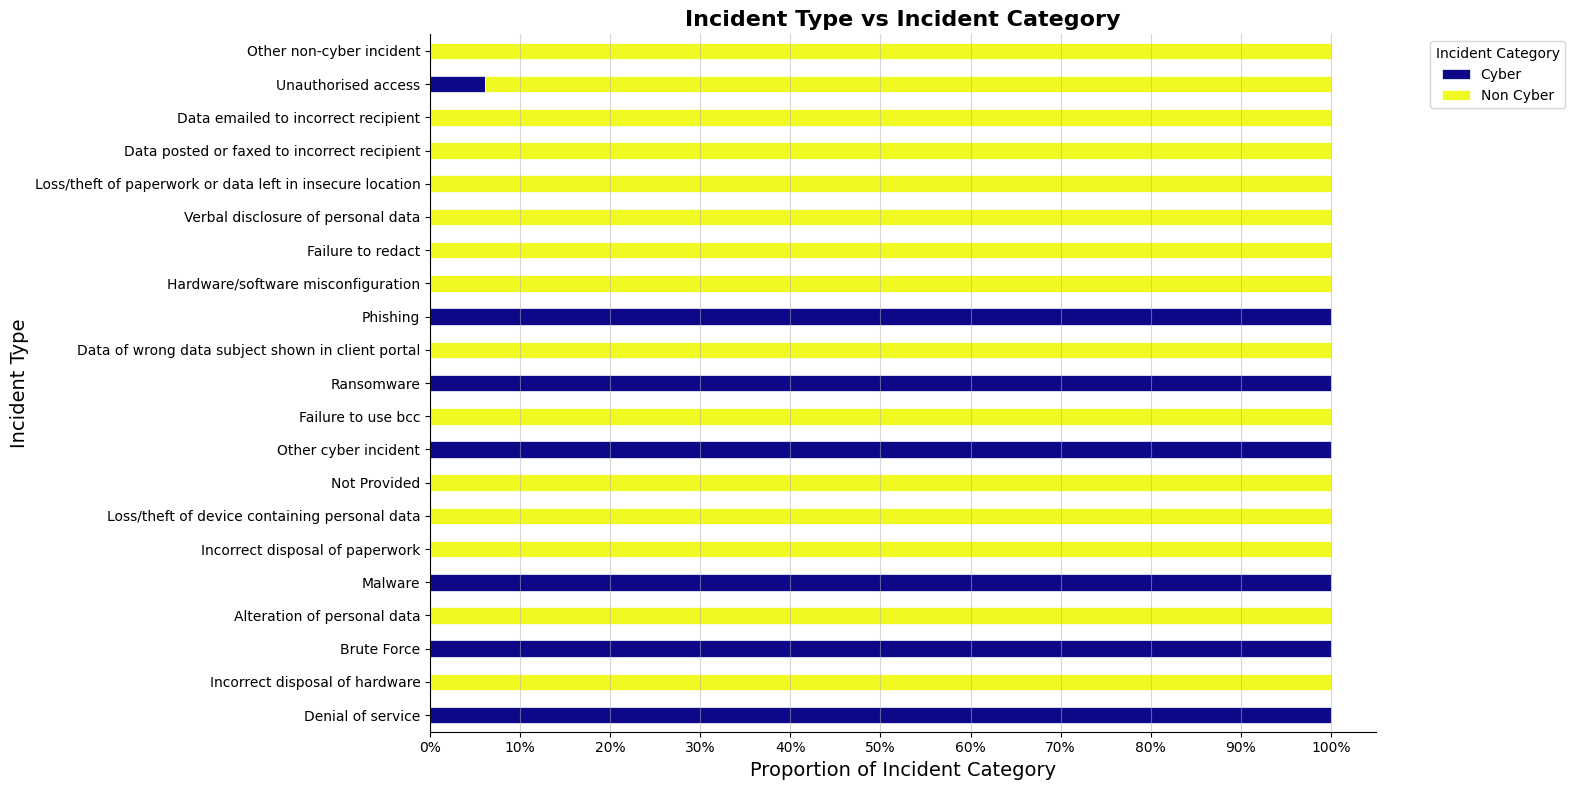

incident_category,Cyber,Non Cyber
incident_type,,
Denial of service,1.000,0.000
Incorrect disposal of hardware,0.000,1.000
Brute Force,1.000,0.000
Alteration of personal data,0.000,1.000
Malware,1.000,0.000
Incorrect disposal of paperwork,0.000,1.000
Loss/theft of device containing personal data,0.000,1.000
Not Provided,0.000,1.000
Other cyber incident,1.000,0.000


In [23]:
# Incident type vs incident category
props, counts = plot_horizontal_stacked_crosstab(
    df_health_unique['incident_type'],
    df_health_unique['incident_category'],
    title='Incident Type vs Incident Category',
    row_label='Incident Type',
    col_label='Incident Category',
)
display(props)

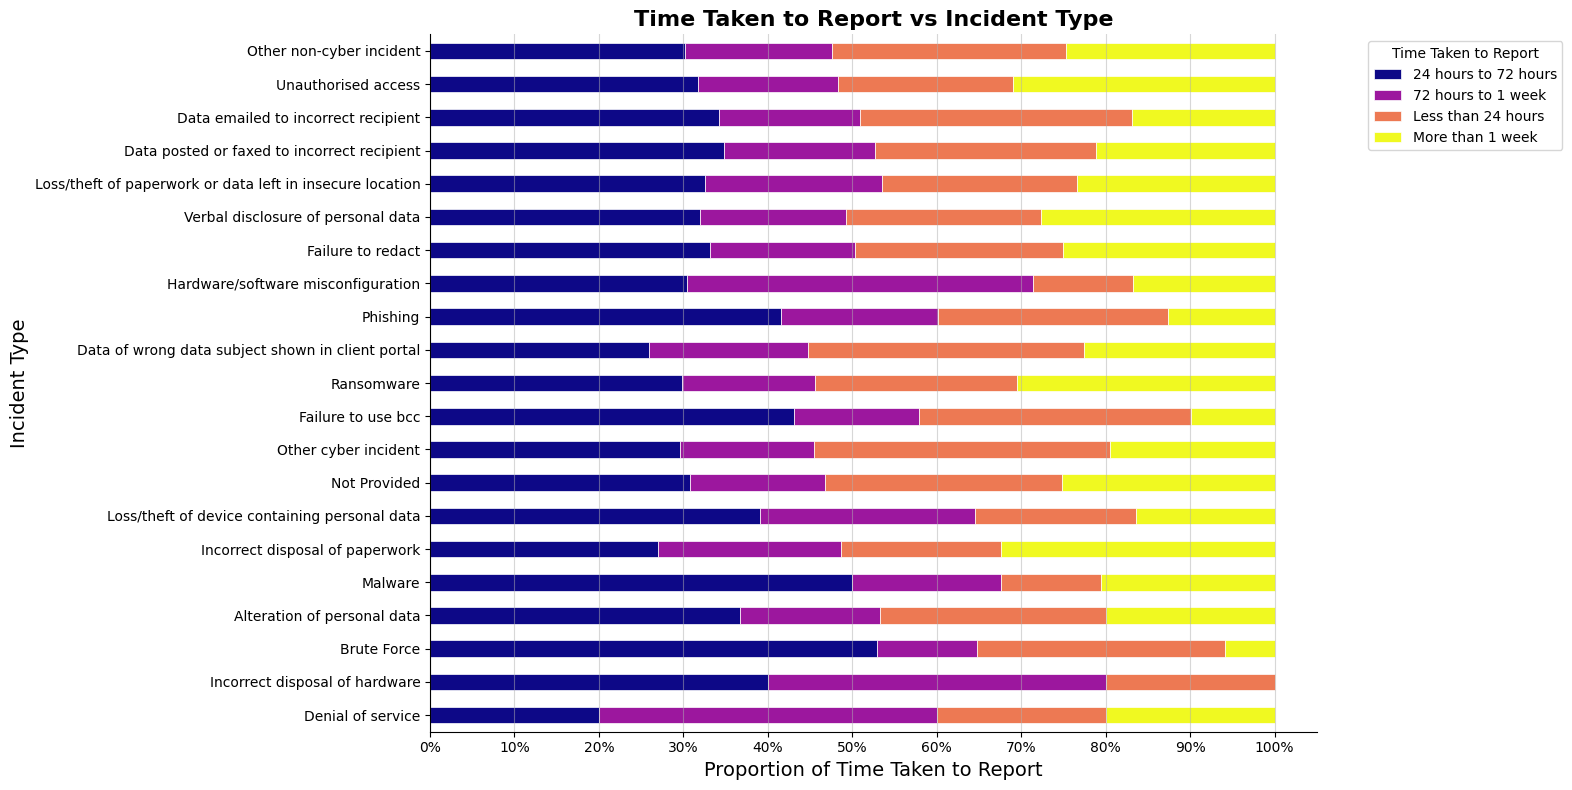

time_taken_to_report,24 hours to 72 hours,72 hours to 1 week,Less than 24 hours,More than 1 week
incident_type,,,,
Denial of service,0.200,0.400,0.200,0.200
Incorrect disposal of hardware,0.400,0.400,0.200,0.000
Brute Force,0.529,0.118,0.294,0.059
Alteration of personal data,0.367,0.167,0.267,0.200
Malware,0.500,0.176,0.118,0.206
Incorrect disposal of paperwork,0.270,0.216,0.189,0.324
Loss/theft of device containing personal data,0.391,0.255,0.191,0.164
Not Provided,0.307,0.161,0.280,0.252
Other cyber incident,0.295,0.159,0.350,0.195


In [24]:
# Time taken to report vs incident type
props, counts = plot_horizontal_stacked_crosstab(
    df_health_unique['incident_type'],
    df_health_unique['time_taken_to_report'],
    title='Time Taken to Report vs Incident Type',
    row_label='Incident Type',
    col_label='Time Taken to Report',
)
display(props)

In [25]:
# Function for plotting a crosstab bar chart
def plot_vertical_stacked_crosstab(
    row_series,
    col_series,
    title,
    row_label=None,
    col_label=None,
    colormap='plasma',
    figsize=(16, 8),
    sort_by_size=True,
    show_table=True
):
    row_label = row_label or row_series.name or "Row"
    col_label = col_label or col_series.name or "Column"

    counts = pd.crosstab(row_series, col_series)
    proportions = pd.crosstab(row_series, col_series, normalize='index')

    if sort_by_size:
        order = counts.sum(axis=1).sort_values(ascending=True).index
        counts = counts.loc[order]
        proportions = proportions.loc[order]

    ax = proportions.plot(
        kind='bar',
        stacked=True,
        figsize=figsize,
        colormap=colormap,
        edgecolor='white',
        linewidth=0.5,
    )

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Proportion of {col_label}', fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylabel(row_label, fontsize=14)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_yticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])
    ax.legend(title=col_label, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', linestyle='-', alpha=0.5)

    plt.tight_layout()
    plt.show()

    if show_table:
        return proportions.round(3), counts
    return None

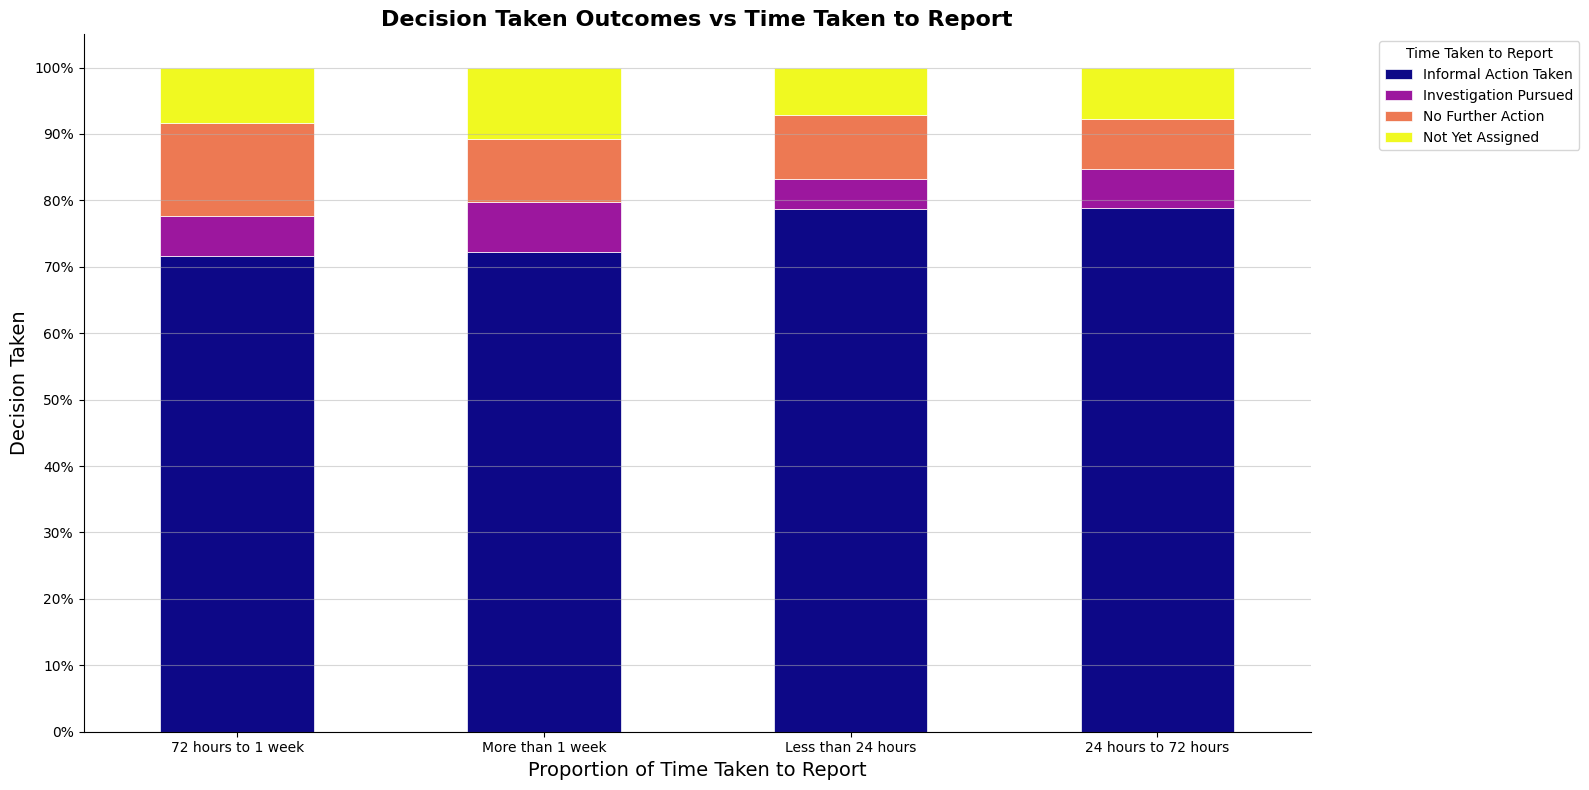

decision_taken,Informal Action Taken,Investigation Pursued,No Further Action,Not Yet Assigned
time_taken_to_report,,,,
72 hours to 1 week,0.717,0.059,0.141,0.083
More than 1 week,0.723,0.076,0.095,0.107
Less than 24 hours,0.786,0.045,0.096,0.072
24 hours to 72 hours,0.788,0.059,0.075,0.078


In [26]:
# Plot decision taken vs time taken to report as a vertical bar chart
props, counts = plot_vertical_stacked_crosstab(
    df_health_unique['time_taken_to_report'],
    df_health_unique['decision_taken'],
    title='Decision Taken Outcomes vs Time Taken to Report',
    row_label='Decision Taken',
    col_label='Time Taken to Report',
)
display(props)

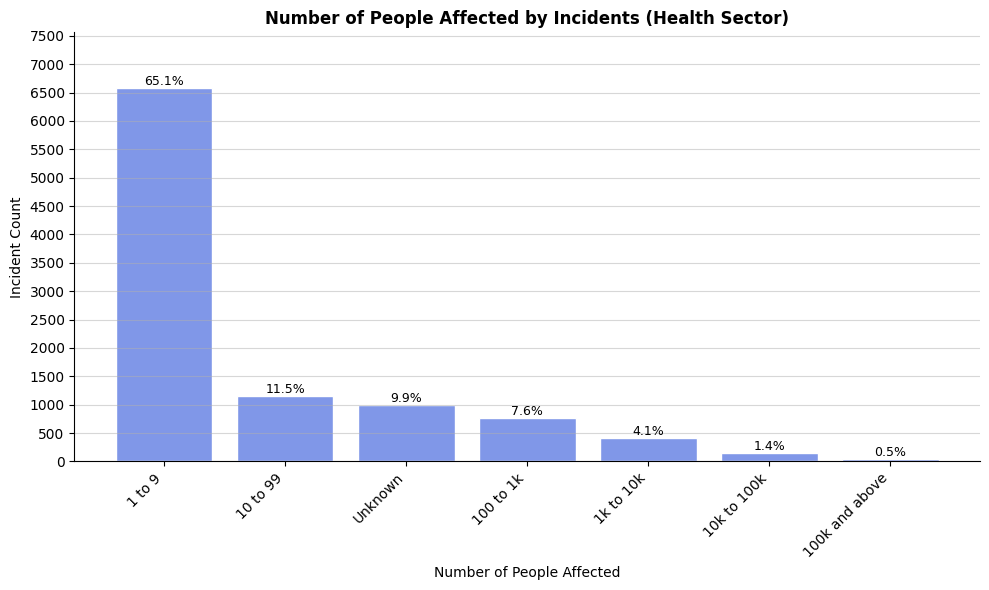

                           count  percent
no_data_subjects_affected                
1 to 9                      6574     65.1
10 to 99                    1157     11.5
Unknown                      996      9.9
100 to 1k                    770      7.6
1k to 10k                    412      4.1
10k to 100k                  143      1.4
100k and above                46      0.5


In [27]:
# Number of people affected (Health sector)
summary = plot_vertical_bar_chart(
    df_health_unique['no_data_subjects_affected'].value_counts(),
    title="Number of People Affected by Incidents (Health Sector)",
    xlabel="Number of People Affected",
    ylabel="Incident Count",
    sort_by='none',
    annotate='percent',
    color="#8097e8",
    step=500
)
print(summary)

In [28]:
# make the df_health_original df a new csv file for the next stages of analysis
# check the columns and data types before saving
df_health_original.info()
#df_health_original.to_csv("data-security-incident-trends-health-sector.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 22879 entries, 65264 to 206136
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   bi_reference               22879 non-null  category
 1   year                       22879 non-null  category
 2   quarter                    22879 non-null  category
 3   data_subject_type          22879 non-null  category
 4   data_type                  22879 non-null  category
 5   decision_taken             22879 non-null  category
 6   incident_category          22879 non-null  category
 7   incident_type              22879 non-null  category
 8   no_data_subjects_affected  22879 non-null  category
 9   time_taken_to_report       22879 non-null  category
dtypes: category(10)
memory usage: 764.5 KB


In [29]:
# create a new df for ML models that includes unique incidents with aggregated data_subject_type and data_type features
df_health_ml = (
    df_health_original
    .groupby("bi_reference", observed=True)
    .agg({
        "year": "first",
        "quarter": "first",
        "data_subject_type": lambda data: ', '.join(sorted(data.unique())),
        "data_type": lambda data: ', '.join(sorted(data.unique())),
        "decision_taken": "first",
        "incident_category": "first",
        "incident_type": "first",
        "no_data_subjects_affected": "first",
        "time_taken_to_report": "first",
    })
    .reset_index()
)

# drop bi_reference as not needed for modelling
df_health_ml = df_health_ml.drop(columns=["bi_reference"])

# drop the 'Not Yet Assigned' rows as they aren't predictable 
df_health_ml = df_health_ml[df_health_ml["decision_taken"] != "Not Yet Assigned"].reset_index(drop=True)

# verify new df
df_health_ml.info()
df_health_ml.to_csv("new-data-security-incident-trends-health-sector.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9250 entries, 0 to 9249
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   year                       9250 non-null   category
 1   quarter                    9250 non-null   category
 2   data_subject_type          9250 non-null   object  
 3   data_type                  9250 non-null   object  
 4   decision_taken             9250 non-null   category
 5   incident_category          9250 non-null   category
 6   incident_type              9250 non-null   category
 7   no_data_subjects_affected  9250 non-null   category
 8   time_taken_to_report       9250 non-null   category
dtypes: category(7), object(2)
memory usage: 209.9+ KB


In [30]:
# check decision taken variables 
df_health_ml["decision_taken"].value_counts()

decision_taken
Informal Action Taken    7670
No Further Action         982
Investigation Pursued     598
Not Yet Assigned            0
Name: count, dtype: int64

In [31]:
# amount of unique incidents per quarter 
incidents_per_quarter = df_health_ml.groupby(["year", "quarter"], observed=True).size().reset_index(name="incident_count")
print(incidents_per_quarter.to_string(index=False))

year quarter  incident_count
2021   Qtr 2             603
2021   Qtr 3             432
2021   Qtr 4             461
2022   Qtr 1             421
2022   Qtr 2             431
2022   Qtr 3             481
2022   Qtr 4             440
2023   Qtr 1             454
2023   Qtr 2             458
2023   Qtr 3             501
2023   Qtr 4             439
2024   Qtr 1             510
2024   Qtr 2             534
2024   Qtr 3             601
2024   Qtr 4             546
2025   Qtr 1             533
2025   Qtr 2             499
2025   Qtr 3             442
2025   Qtr 4             464
